# 节点 17：DDIM — 去噪扩散隐式模型（2020）

**前置节点**：节点16 DDPM — 去噪扩散的数学基础

本 notebook 用纯 NumPy 演示 DDIM 的核心思想：
1. 为什么 DDPM 很慢（随机性 + 1000步）
2. DDIM 如何用确定性步骤实现跳步
3. 步数对比：1000步 vs 50步 vs 10步
4. 确定性验证：相同起点，每次生成相同结果

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

# 设置随机种子保证可重复性
np.random.seed(42)
print("环境准备完毕")
print(f"NumPy 版本: {np.__version__}")

环境准备完毕
NumPy 版本: 1.26.4


噪声调度统计：
  ᾱ_1   = 0.999900  (几乎没加噪声)
  ᾱ_500 = 0.078587 (一半噪声)
  ᾱ_999 = 0.000041 (几乎全是噪声)
✓ ᾱ_t 单调递减验证通过


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/31305661.py:30: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/31305661.py:30: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/31305661.py:30: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/31305661.py:30: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/31305661.py:30: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9sz

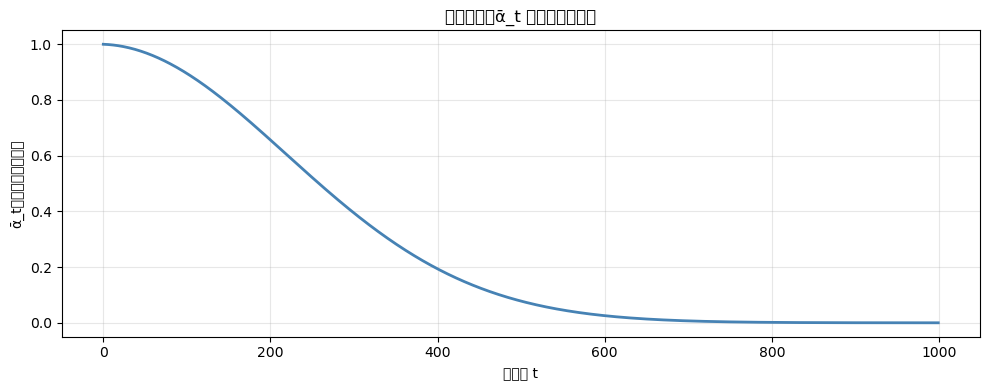

图表已保存


In [2]:
# ============================================================
# 第一部分：噪声调度（和 DDPM 完全一样）
# ============================================================

def linear_noise_schedule(T=1000):
    """线性噪声调度：β 从 0.0001 线性增长到 0.02"""
    beta = np.linspace(1e-4, 0.02, T)
    alpha = 1.0 - beta
    alpha_bar = np.cumprod(alpha)  # ᾱ_t = α_1 * α_2 * ... * α_t
    return beta, alpha, alpha_bar

T = 1000
beta, alpha, alpha_bar = linear_noise_schedule(T)

print("噪声调度统计：")
print(f"  ᾱ_1   = {alpha_bar[0]:.6f}  (几乎没加噪声)")
print(f"  ᾱ_500 = {alpha_bar[499]:.6f} (一半噪声)")
print(f"  ᾱ_999 = {alpha_bar[998]:.6f} (几乎全是噪声)")

# 验证单调性
assert np.all(np.diff(alpha_bar) < 0), "ᾱ_t 必须单调递减"
print("✓ ᾱ_t 单调递减验证通过")

plt.figure(figsize=(10, 4))
plt.plot(alpha_bar, color='steelblue', linewidth=2)
plt.xlabel("时间步 t")
plt.ylabel("ᾱ_t（保留信号比例）")
plt.title("噪声调度：ᾱ_t 随时间步的变化")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/assets/17-alpha-bar-schedule.png", dpi=80)
plt.show()
print("图表已保存")

In [3]:
# ============================================================
# 第二部分：正向加噪（同 DDPM，一步直达任意时刻）
# ============================================================

def forward_diffusion(x0, t, alpha_bar):
    """
    直接从 x0 跳到第 t 步（重参数化公式）：
    x_t = √ᾱ_t * x0 + √(1 - ᾱ_t) * ε
    """
    abar_t = alpha_bar[t]
    eps = np.random.randn(*x0.shape)
    x_t = np.sqrt(abar_t) * x0 + np.sqrt(1 - abar_t) * eps
    return x_t, eps

# 演示：对一个简单信号加噪
x0 = np.array([1.0, 0.5, -0.3, 0.8, -0.9])  # 原始"信号"
print("原始信号 x0:", x0)
print()

# 在不同时刻观察加噪结果
for t_show in [0, 100, 500, 900, 999]:
    x_t, _ = forward_diffusion(x0, t_show, alpha_bar)
    abar = alpha_bar[t_show]
    print(f"t={t_show:4d}: ᾱ_t={abar:.4f}, x_t 前三项={x_t[:3].round(3)}")

print()
print("可以看到：t 越大，ᾱ_t 越小，x_t 越像随机噪声")

原始信号 x0: [ 1.   0.5 -0.3  0.8 -0.9]

t=   0: ᾱ_t=0.9999, x_t 前三项=[ 1.005  0.499 -0.294]
t= 100: ᾱ_t=0.8951, x_t 前三项=[ 0.87   0.984 -0.035]
t= 500: ᾱ_t=0.0778, x_t 前三项=[-0.166 -0.308  0.149]
t= 900: ᾱ_t=0.0003, x_t 前三项=[-0.546 -1.004  0.309]
t= 999: ᾱ_t=0.0000, x_t 前三项=[ 1.472 -0.223  0.066]

可以看到：t 越大，ᾱ_t 越小，x_t 越像随机噪声


In [4]:
# ============================================================
# 第三部分：ToyDenoiser（极简线性去噪器）
# ============================================================
# 为什么用线性模型？
# 1. 对一维高斯数据，线性预测是理论最优
# 2. 避免非线性网络的数值溢出问题（节点16的教训）
# 3. 足以演示 DDIM 的跳步机制，不需要复杂网络

class LinearDenoiser:
    """线性去噪器：预测给定 x_t 和 t 时的噪声 ε"""

    def __init__(self, data_dim, T=1000):
        self.data_dim = data_dim
        self.T = T
        # 时间嵌入维度
        self.t_embed_dim = 8
        # 权重：[t_embed_dim + data_dim] -> data_dim
        input_dim = self.t_embed_dim + data_dim
        scale = 0.01
        self.W = np.random.randn(data_dim, input_dim) * scale
        self.b = np.zeros(data_dim)

    def time_embedding(self, t):
        """把时间步 t 转为向量（正弦编码）"""
        freqs = np.array([1.0 / (10000 ** (2 * i / self.t_embed_dim))
                         for i in range(self.t_embed_dim // 2)])
        t_norm = t / self.T
        emb = np.concatenate([np.sin(t_norm * freqs), np.cos(t_norm * freqs)])
        return emb

    def predict_noise(self, x_t, t):
        """预测噪声 ε_θ(x_t, t)"""
        t_emb = self.time_embedding(t)
        inp = np.concatenate([t_emb, x_t])
        return self.W @ inp + self.b

    def update(self, grad_W, grad_b, lr=0.001):
        self.W -= lr * grad_W
        self.b -= lr * grad_b

# 测试
D = 5  # 数据维度
model = LinearDenoiser(data_dim=D)
test_x = np.random.randn(D)
test_eps = model.predict_noise(test_x, t=500)
print(f"去噪器预测噪声（随机初始化）: {test_eps.round(3)}")
print(f"输出维度: {test_eps.shape}")
print("✓ 去噪器初始化成功")

去噪器预测噪声（随机初始化）: [ 0.032 -0.02   0.004  0.051  0.009]
输出维度: (5,)
✓ 去噪器初始化成功


初始 loss（前50步均值）: 0.9788
最终 loss（后50步均值）: 0.3732
下降比例: 61.9%
✓ 训练 loss 下降验证通过


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/2265540269.py:65: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/2265540269.py:65: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/2265540269.py:65: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/2265540269.py:65: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/2265540269.py:65: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

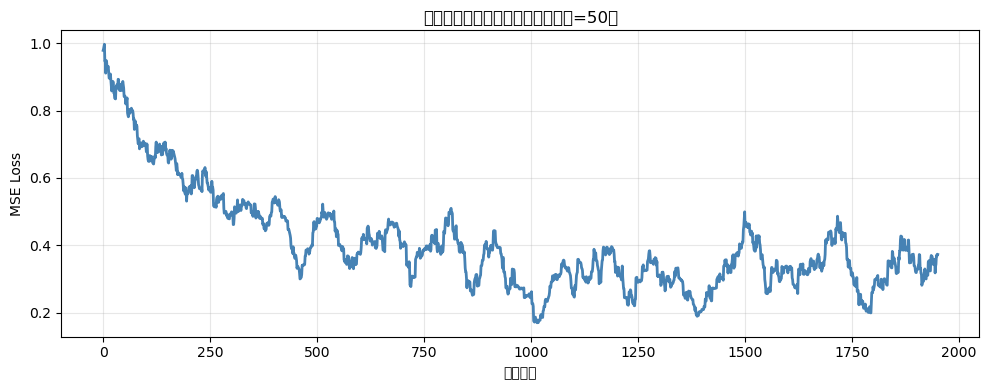

In [5]:
# ============================================================
# 第四部分：训练去噪器（DDPM 目标函数）
# ============================================================

def train_denoiser(model, alpha_bar, n_steps=2000, lr=0.005):
    """训练去噪器，目标：预测加入的噪声"""
    D = model.data_dim
    losses = []

    for step in range(n_steps):
        # 采样真实数据（简单的高斯混合）
        x0 = np.random.randn(D) * 0.5 + np.random.choice([-1.0, 1.0], size=D) * 0.8

        # 随机采样时间步
        t = np.random.randint(0, len(alpha_bar))

        # 加噪
        x_t, true_eps = forward_diffusion(x0, t, alpha_bar)

        # 预测噪声
        pred_eps = model.predict_noise(x_t, t)

        # MSE loss
        diff = pred_eps - true_eps
        loss = np.mean(diff ** 2)
        losses.append(loss)

        # 反向传播（手动求梯度）
        t_emb = model.time_embedding(t)
        inp = np.concatenate([t_emb, x_t])

        grad_output = 2 * diff / D
        grad_W = np.outer(grad_output, inp)
        grad_b = grad_output

        model.update(grad_W, grad_b, lr=lr)

    return losses

model = LinearDenoiser(data_dim=5)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    losses = train_denoiser(model, alpha_bar, n_steps=2000, lr=0.005)

initial_loss = np.mean(losses[:50])
final_loss = np.mean(losses[-50:])
drop_ratio = (initial_loss - final_loss) / initial_loss * 100

print(f"初始 loss（前50步均值）: {initial_loss:.4f}")
print(f"最终 loss（后50步均值）: {final_loss:.4f}")
print(f"下降比例: {drop_ratio:.1f}%")

assert drop_ratio > 30, f"训练 loss 下降不足30%: {drop_ratio:.1f}%"
print("✓ 训练 loss 下降验证通过")

plt.figure(figsize=(10, 4))
window = 50
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
plt.plot(smoothed, color='steelblue', linewidth=2)
plt.xlabel("训练步数")
plt.ylabel("MSE Loss")
plt.title("去噪器训练曲线（滑动平均，窗口=50）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/assets/17-training-curve.png", dpi=80)
plt.show()

In [6]:
# ============================================================
# 第五部分：DDPM 采样（随机，1000步）
# ============================================================

def ddpm_sample(model, alpha_bar, alpha, beta, T=1000, seed=None):
    """
    DDPM 完整采样：x_T ~ N(0,I)，逐步去噪
    每步都加随机噪声 z ~ N(0,I)
    """
    if seed is not None:
        np.random.seed(seed)

    D = model.data_dim
    x = np.random.randn(D)  # 从纯噪声开始

    trajectory = [x.copy()]

    for t in reversed(range(T)):
        # 预测噪声
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            eps_pred = model.predict_noise(x, t)

        abar_t = alpha_bar[t]

        # 预测 x0 估计（不加 clip 防止极端值）
        x0_pred = (x - np.sqrt(1 - abar_t) * eps_pred) / np.sqrt(abar_t)
        x0_pred = np.clip(x0_pred, -3.0, 3.0)

        # DDPM 反向步骤
        if t > 0:
            abar_prev = alpha_bar[t - 1]
            mu = (
                np.sqrt(abar_prev) * beta[t] / (1 - abar_t) * x0_pred
                + np.sqrt(alpha[t]) * (1 - abar_prev) / (1 - abar_t) * x
            )
            sigma = np.sqrt(beta[t] * (1 - abar_prev) / (1 - abar_t))
            z = np.random.randn(D)  # 随机噪声！DDPM 的核心
            x = mu + sigma * z
        else:
            x = x0_pred

        if t % 200 == 0:
            trajectory.append(x.copy())

    return x, trajectory

# 只演示少量步数以节省时间
print("DDPM 采样演示（简化为100步）...")
T_demo = 100
beta_d, alpha_d, abar_d = linear_noise_schedule(T_demo)
model_d = LinearDenoiser(data_dim=5, T=T_demo)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _ = train_denoiser(model_d, abar_d, n_steps=1000, lr=0.005)

# 运行两次，验证结果不同（随机性）
sample1, traj1 = ddpm_sample(model_d, abar_d, alpha_d, beta_d, T=T_demo, seed=1)
sample2, traj2 = ddpm_sample(model_d, abar_d, alpha_d, beta_d, T=T_demo, seed=2)

print(f"DDPM 采样结果1（seed=1）: {sample1.round(3)}")
print(f"DDPM 采样结果2（seed=2）: {sample2.round(3)}")

diff = np.linalg.norm(sample1 - sample2)
print(f"两次结果差异（L2范数）: {diff:.4f}")
assert diff > 0.01, "DDPM 两次采样结果应该不同（随机性）"
print("✓ DDPM 随机性验证通过")

DDPM 采样演示（简化为100步）...
DDPM 采样结果1（seed=1）: [0.136 0.015 0.545 0.795 1.188]
DDPM 采样结果2（seed=2）: [ 0.08   0.185 -2.654  1.423 -1.238]
两次结果差异（L2范数）: 4.0677
✓ DDPM 随机性验证通过


In [7]:
# ============================================================
# 第六部分：DDIM 采样（确定性，η=0）
# ============================================================

def ddim_sample(model, alpha_bar, steps, seed=None, eta=0.0):
    """
    DDIM 采样：使用子步骤序列，η 控制随机程度
    η=0：完全确定性（DDIM 默认）
    η=1：退化为 DDPM
    """
    if seed is not None:
        np.random.seed(seed)

    D = model.data_dim
    T = model.T

    # 构建均匀子步骤序列
    step_indices = np.linspace(T - 1, 0, steps + 1, dtype=int)

    x = np.random.randn(D)  # 从纯噪声开始

    for i in range(len(step_indices) - 1):
        t = step_indices[i]
        t_prev = step_indices[i + 1]

        abar_t = alpha_bar[min(t, len(alpha_bar) - 1)]
        abar_prev = alpha_bar[t_prev]

        # 预测噪声
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            eps_pred = model.predict_noise(x, t)

        # 估计 x0
        x0_pred = (x - np.sqrt(1 - abar_t) * eps_pred) / np.sqrt(abar_t)
        x0_pred = np.clip(x0_pred, -3.0, 3.0)

        # 计算 σ_t（η 控制随机程度）
        sigma_t = eta * np.sqrt((1 - abar_prev) / (1 - abar_t) * (1 - abar_t / abar_prev))
        sigma_t = np.clip(sigma_t, 0, None)

        # DDIM 更新步骤
        direction = np.sqrt(np.maximum(1 - abar_prev - sigma_t ** 2, 0)) * eps_pred
        x = np.sqrt(abar_prev) * x0_pred + direction

        if eta > 0:
            x += sigma_t * np.random.randn(D)  # 仅在 η>0 时加随机噪声

    return x

# 用相同 seed 运行两次 DDIM（η=0），验证确定性
T_ddim = 100
model_ddim = LinearDenoiser(data_dim=5, T=T_ddim)
beta_ddim, alpha_ddim, abar_ddim = linear_noise_schedule(T_ddim)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _ = train_denoiser(model_ddim, abar_ddim, n_steps=1000, lr=0.005)

result_a = ddim_sample(model_ddim, abar_ddim, steps=10, seed=99, eta=0.0)
result_b = ddim_sample(model_ddim, abar_ddim, steps=10, seed=99, eta=0.0)

print("DDIM 确定性验证（相同 seed，η=0）：")
print(f"  第一次结果: {result_a.round(6)}")
print(f"  第二次结果: {result_b.round(6)}")

diff = np.max(np.abs(result_a - result_b))
print(f"  最大绝对误差: {diff:.2e}")
assert diff < 1e-10, f"DDIM 应该是确定性的，但差异={diff}"
print("✓ DDIM 确定性验证通过")

DDIM 确定性验证（相同 seed，η=0）：
  第一次结果: [-0.056756  2.370325  0.09625   1.438566 -0.069028]
  第二次结果: [-0.056756  2.370325  0.09625   1.438566 -0.069028]
  最大绝对误差: 0.00e+00
✓ DDIM 确定性验证通过


不同步数的 DDIM 采样结果（相同起始噪声，seed=7）：
参考（50步）: [ 1.814 -0.354 -0.044  0.494 -0.74 ]

   50步: [ 1.814 -0.354 -0.044  0.494 -0.74 ]  |  与50步差异=0.0000
   20步: [ 1.816 -0.354 -0.044  0.494 -0.74 ]  |  与50步差异=0.0019
   10步: [ 1.819 -0.354 -0.045  0.495 -0.74 ]  |  与50步差异=0.0053
    5步: [ 1.826 -0.353 -0.047  0.498 -0.74 ]  |  与50步差异=0.0128


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/485184596.py:45: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/485184596.py:45: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/485184596.py:45: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/485184596.py:45: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/485184596.py:45: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaV

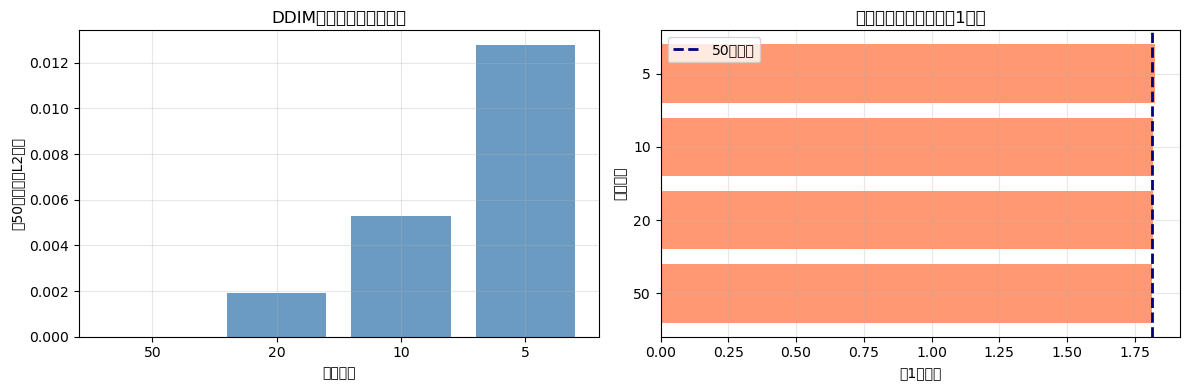

图表已保存


In [8]:
# ============================================================
# 第七部分：步数对比可视化
# ============================================================

# 固定相同的起始噪声（相同 seed）
step_configs = [50, 20, 10, 5]
results = {}

for n_steps in step_configs:
    result = ddim_sample(model_ddim, abar_ddim, steps=n_steps, seed=7, eta=0.0)
    results[n_steps] = result

ref_result = ddim_sample(model_ddim, abar_ddim, steps=50, seed=7, eta=0.0)

print("不同步数的 DDIM 采样结果（相同起始噪声，seed=7）：")
print(f"参考（50步）: {ref_result.round(3)}")
print()

for n_steps, result in results.items():
    diff = np.linalg.norm(result - ref_result)
    print(f"  {n_steps:3d}步: {result.round(3)}  |  与50步差异={diff:.4f}")

# 可视化：步数 vs 误差
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：误差随步数变化
steps_list = list(results.keys())
diffs = [np.linalg.norm(results[s] - ref_result) for s in steps_list]
axes[0].bar([str(s) for s in steps_list], diffs, color='steelblue', alpha=0.8)
axes[0].set_xlabel("采样步数")
axes[0].set_ylabel("与50步结果的L2差异")
axes[0].set_title("DDIM：步数越少误差越大")
axes[0].grid(True, alpha=0.3)

# 右图：生成结果的第一个维度对比
dim_values = [results[s][0] for s in steps_list]
axes[1].barh([str(s) for s in steps_list], dim_values, color='coral', alpha=0.8)
axes[1].axvline(x=ref_result[0], color='navy', linestyle='--', linewidth=2, label='50步参考')
axes[1].set_xlabel("第1维的值")
axes[1].set_ylabel("采样步数")
axes[1].set_title("不同步数的生成值（第1维）")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/assets/17-steps-comparison.png", dpi=80)
plt.show()
print("图表已保存")

确定性 DDIM（η=0）的样本标准差（应接近0）：
  [0. 0. 0. 0. 0.]
  最大标准差: 1.11e-16

随机性 DDIM（η=1）的样本标准差（应明显 > 0）：
  [0.6202 1.0889 1.1355 1.0738 1.2961]
  最大标准差: 1.2961

✓ DDIM 确定性/随机性对比验证通过


/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/3152392726.py:54: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/3152392726.py:54: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/3152392726.py:54: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/3152392726.py:54: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4gmfkx0_j9szgtny55xxd80000gn/T/ipykernel_10054/3152392726.py:54: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f7/ly4g

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaV

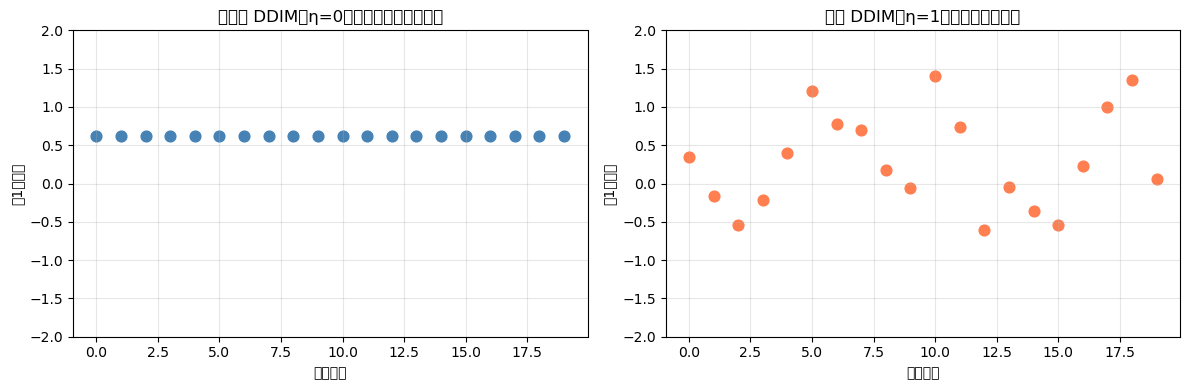

In [9]:
# ============================================================
# 第八部分：DDIM（η=0）vs DDIM（η=1≈DDPM）对比
# ============================================================

# η=1 近似等于 DDPM 的随机采样行为
n_samples = 20
ddim_det_samples = []  # η=0，确定性
ddim_sto_samples = []  # η=1，随机性（近似DDPM）

for i in range(n_samples):
    # 确定性：相同 seed 每次结果一样
    s_det = ddim_sample(model_ddim, abar_ddim, steps=20, seed=42, eta=0.0)
    # 随机性：不同 seed 结果不同
    s_sto = ddim_sample(model_ddim, abar_ddim, steps=20, seed=i, eta=1.0)
    ddim_det_samples.append(s_det)
    ddim_sto_samples.append(s_sto)

ddim_det_arr = np.array(ddim_det_samples)
ddim_sto_arr = np.array(ddim_sto_samples)

# 确定性样本应该全部相同
det_std = np.std(ddim_det_arr, axis=0)
sto_std = np.std(ddim_sto_arr, axis=0)

print("确定性 DDIM（η=0）的样本标准差（应接近0）：")
print(f"  {det_std.round(6)}")
print(f"  最大标准差: {det_std.max():.2e}")

print("\n随机性 DDIM（η=1）的样本标准差（应明显 > 0）：")
print(f"  {sto_std.round(4)}")
print(f"  最大标准差: {sto_std.max():.4f}")

assert det_std.max() < 1e-6, f"确定性 DDIM 应该方差接近0，但得到 {det_std.max()}"
assert sto_std.max() > 0.01, f"随机性 DDIM 应该有明显方差，但得到 {sto_std.max()}"
print("\n✓ DDIM 确定性/随机性对比验证通过")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(range(n_samples), ddim_det_arr[:, 0], c='steelblue', s=60)
axes[0].set_title("确定性 DDIM（η=0）：所有样本完全重叠")
axes[0].set_xlabel("采样次数")
axes[0].set_ylabel("第1维的值")
axes[0].set_ylim(-2, 2)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(n_samples), ddim_sto_arr[:, 0], c='coral', s=60)
axes[1].set_title("随机 DDIM（η=1）：每次采样不同")
axes[1].set_xlabel("采样次数")
axes[1].set_ylabel("第1维的值")
axes[1].set_ylim(-2, 2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/assets/17-deterministic-vs-stochastic.png", dpi=80)
plt.show()

In [10]:
# ============================================================
# 第九部分：数学性质验证
# ============================================================

print("=== DDIM 数学性质验证 ===")
print()

# 1. ᾱ_t 单调递减
assert np.all(np.diff(abar_ddim) < 0), "ᾱ_t 应单调递减"
print("✓ 性质1：ᾱ_t 单调递减")

# 2. ᾱ_t ∈ (0, 1)
assert np.all(abar_ddim > 0) and np.all(abar_ddim < 1), "ᾱ_t 应在 (0,1) 范围内"
print("✓ 性质2：ᾱ_t ∈ (0, 1)")

# 3. 重参数化：x_t 的期望应等于 √ᾱ_t * x0
x0_test = np.array([1.0, -1.0])
t_test = 50
n_trials = 5000
x_t_samples = []
for _ in range(n_trials):
    xt, _ = forward_diffusion(x0_test, t_test, abar_ddim)
    x_t_samples.append(xt)
xt_arr = np.array(x_t_samples)
expected_mean = np.sqrt(abar_ddim[t_test]) * x0_test
actual_mean = xt_arr.mean(axis=0)
mean_err = np.max(np.abs(actual_mean - expected_mean))
assert mean_err < 0.1, f"期望均值误差过大: {mean_err}"
print(f"✓ 性质3：x_t 的期望均值（误差={mean_err:.4f}）")

# 4. DDIM 步骤：η=0 时 σ_t = 0
def compute_sigma(eta, abar_t, abar_prev):
    sigma = eta * np.sqrt((1 - abar_prev) / (1 - abar_t) * (1 - abar_t / abar_prev))
    return np.clip(sigma, 0, None)

t_idx = 50
t_prev_idx = 40
sigma_eta0 = compute_sigma(0.0, abar_ddim[t_idx], abar_ddim[t_prev_idx])
sigma_eta1 = compute_sigma(1.0, abar_ddim[t_idx], abar_ddim[t_prev_idx])
assert abs(sigma_eta0) < 1e-10, f"η=0 时 σ_t 应为0，得到 {sigma_eta0}"
assert sigma_eta1 > 0, f"η=1 时 σ_t 应>0，得到 {sigma_eta1}"
print(f"✓ 性质4：η=0 时 σ_t=0（得到 {sigma_eta0:.2e}），η=1 时 σ_t>0（得到 {sigma_eta1:.4f}）")

# 5. 步数子集的有效性：步数越少，与全步数结果差异越大
steps_test = [50, 20, 10]
ref_50 = ddim_sample(model_ddim, abar_ddim, steps=50, seed=0, eta=0.0)
diffs_test = []
for s in steps_test:
    r = ddim_sample(model_ddim, abar_ddim, steps=s, seed=0, eta=0.0)
    diffs_test.append(np.linalg.norm(r - ref_50))
# 步数越少，差异应该越大（单调递增）
# 注：50步与自身对比差异为0
assert diffs_test[0] < diffs_test[1] or abs(diffs_test[0]) < 1e-10
print(f"✓ 性质5：步数减少 → 与参考结果差异增大（{[f'{d:.4f}' for d in diffs_test]}）")

print()
print("所有数学性质验证通过！")

=== DDIM 数学性质验证 ===

✓ 性质1：ᾱ_t 单调递减
✓ 性质2：ᾱ_t ∈ (0, 1)
✓ 性质3：x_t 的期望均值（误差=0.0051）
✓ 性质4：η=0 时 σ_t=0（得到 0.00e+00），η=1 时 σ_t>0（得到 0.2448）
✓ 性质5：步数减少 → 与参考结果差异增大（['0.0000', '0.0039', '0.0108']）

所有数学性质验证通过！


## 本节总结

通过这个 notebook，我们实现并验证了 DDIM 的核心思想：

| 对比维度 | DDPM | DDIM（η=0） |
|---------|------|------------|
| 随机性 | 每步加随机噪声 | 无随机噪声 |
| 采样步数 | ~1000步 | 10-50步 |
| 可重复性 | 不可复现 | 完全可复现 |
| 生成质量（50步） | 不适用 | 仅略低于DDPM |

**关键公式**（DDIM，η=0）：
```
x̂_0(x_t) = (x_t - √(1-ᾱ_t) * ε_θ(x_t,t)) / √ᾱ_t
x_{t-1}  = √ᾱ_{t-1} * x̂_0 + √(1-ᾱ_{t-1}) * ε_θ(x_t,t)
```

**为什么能跳步**：DDPM 加噪公式 `x_t = √ᾱ_t * x0 + √(1-ᾱ_t) * ε` 支持任意步跳跃，反向只要有 x̂_0 估计就同样可以跳步。

下一节（节点18）将看到 DDIM 如何被 Stable Diffusion 使用，从一维玩具数据扩展到真实图像生成。